# Client 2 : Modèle de prédiction de l'âge

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV

## Import des valeurs

In [149]:
df_raw = pd.read_csv('../../data/Data_Arbre_Clean.csv')
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10418 entries, 0 to 10417
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   X               10418 non-null  float64
 1   Y               10418 non-null  float64
 2   clc_quartier    9933 non-null   str    
 3   clc_secteur     10415 non-null  str    
 4   id_arbre        10399 non-null  float64
 5   haut_tot        10418 non-null  float64
 6   haut_tronc      10418 non-null  float64
 7   tronc_diam      10405 non-null  float64
 8   fk_arb_etat     10418 non-null  str    
 9   fk_stadedev     9331 non-null   str    
 10  fk_port         10273 non-null  str    
 11  fk_pied         10297 non-null  str    
 12  fk_situation    10417 non-null  str    
 13  fk_revetement   9461 non-null   object 
 14  dte_plantation  610 non-null    str    
 15  age_estim       10415 non-null  float64
 16  clc_nbr_diag    8312 non-null   float64
 17  dte_abattage    778 non-null    str    
 1

In [150]:
df_raw.head()

,X,Y,clc_quartier,clc_secteur,id_arbre,haut_tot,haut_tronc,tronc_diam,fk_arb_etat,fk_stadedev,...,fk_revetement,dte_plantation,age_estim,clc_nbr_diag,dte_abattage,villeca,nomfrancais,nomlatin,feuillage,remarquable
0,1.720320e+06,8.294619e+06,Quartier du Centre-Ville,Boulevard Richelieu,24.0,0.0,0.0,0.0,SUPPRIMÉ,NaN,...,NaN,NaN,0.0,0.0,2015-07-01T00:00:00Z,VILLE,NaN,NaN,NaN,False
1,1.720898e+06,8.293531e+06,Quartier du Centre-Ville,Boulevard Léon Blum,24.0,0.0,0.0,0.0,ABATTU,NaN,...,NaN,NaN,0.0,0.0,NaN,VILLE,NaN,NaN,NaN,False
2,1.720894e+06,8.293542e+06,Quartier du Centre-Ville,Boulevard Léon Blum,53.0,0.0,0.0,0.0,SUPPRIMÉ,NaN,...,NaN,NaN,0.0,0.0,NaN,VILLE,NaN,NaN,NaN,False
3,1.720902e+06,8.293545e+06,Quartier du Centre-Ville,Boulevard Léon Blum,54.0,0.0,0.0,0.0,SUPPRIMÉ,NaN,...,NaN,NaN,0.0,0.0,NaN,VILLE,NaN,NaN,NaN,False
4,1.721089e+06,8.293619e+06,Quartier du Centre-Ville,Boulevard Léon Blum,63.0,0.0,0.0,0.0,ABATTU,NaN,...,NaN,NaN,0.0,0.0,NaN,VILLE,NaN,NaN,NaN,False


In [151]:
# Données numériques
col_num = ['haut_tot', 'haut_tronc', 'tronc_diam']

# Données qualitatives
col_qual = ['fk_stadedev', 'nomlatin']

In [152]:
# Filtrage des colonnes
df = df_raw[col_num + col_qual + ['age_estim']].copy()
df = df.dropna(subset=["age_estim"])

## Affichage des données

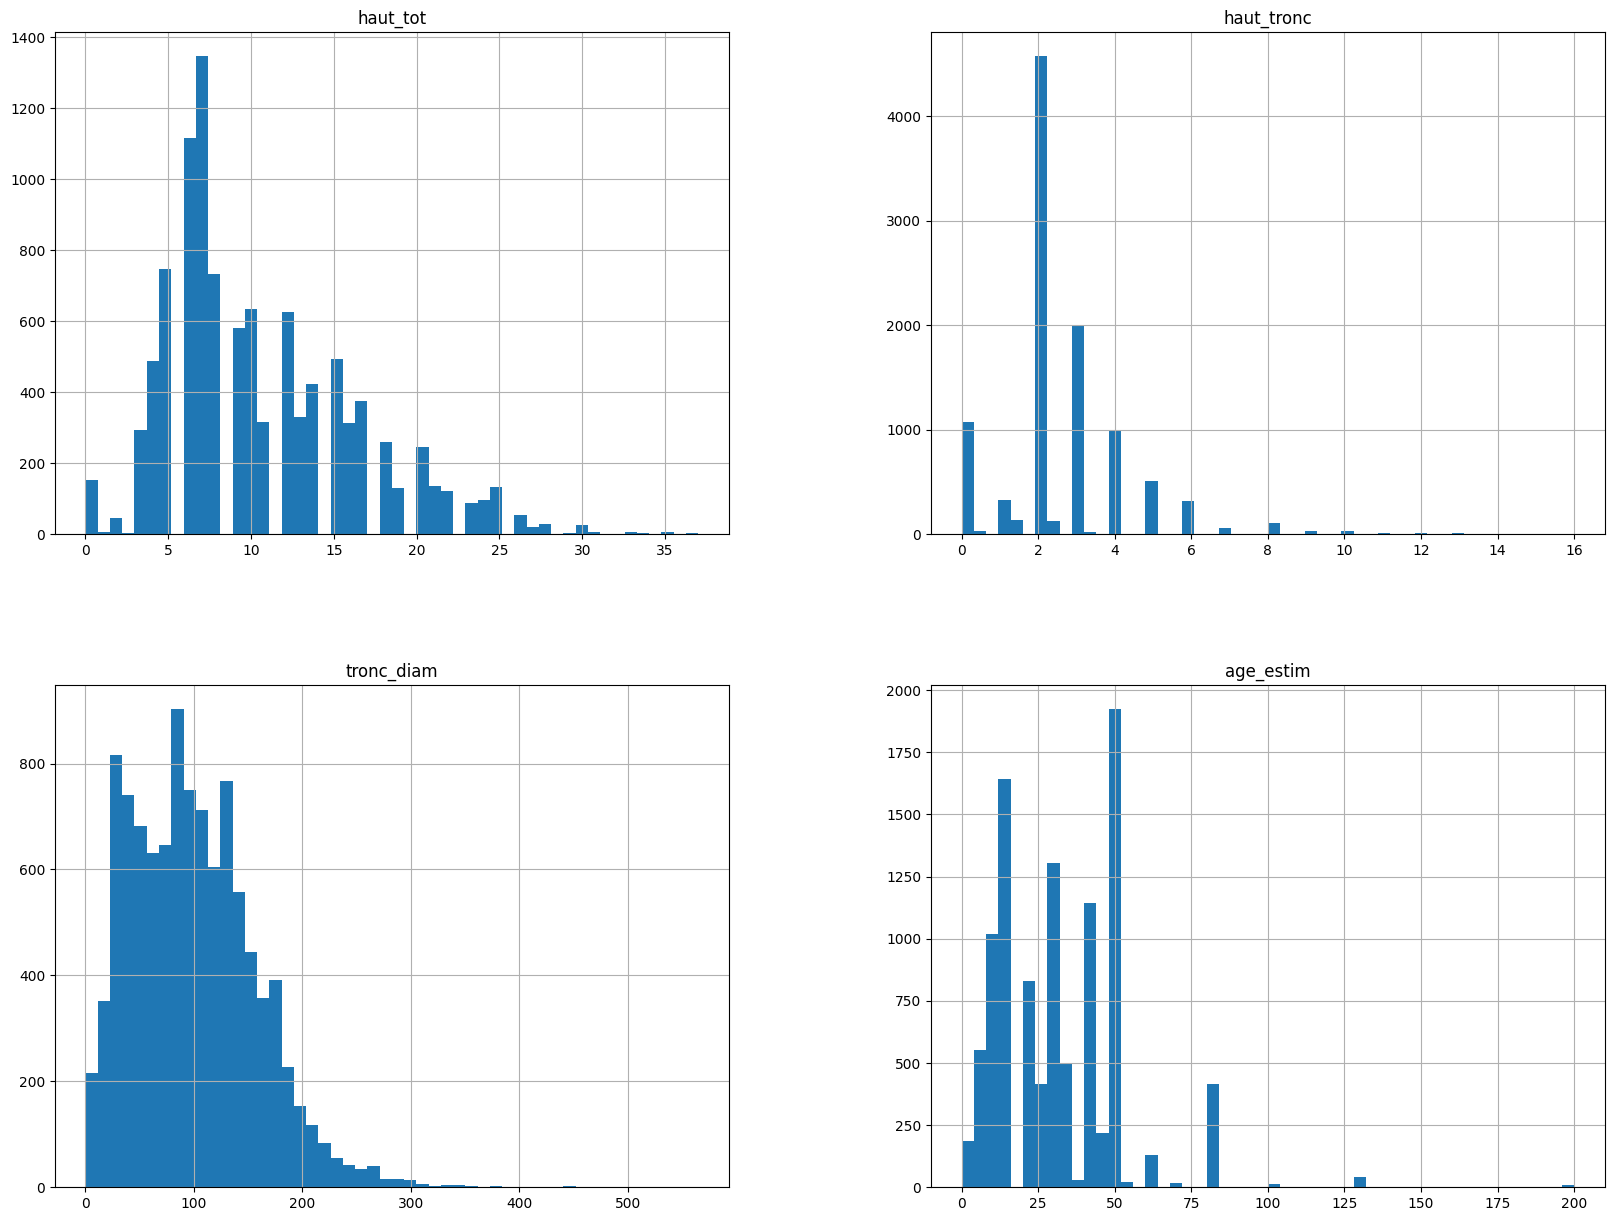

In [153]:
df.hist(bins=50, figsize=(20,15))
plt.show()

> On remarque que les données sont plutôt bien réparties cependant il y a beaucoup de valeurs manquantes

## Matrice de corrélation

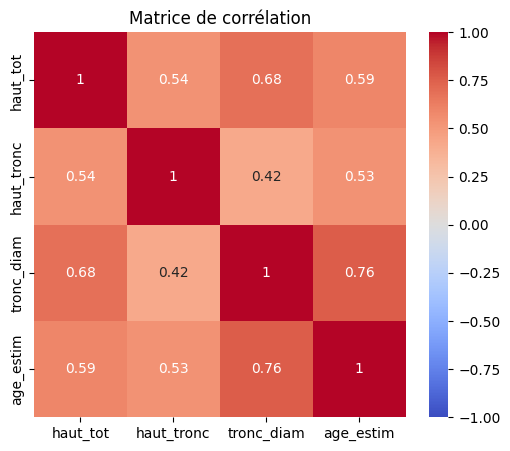

In [154]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title('Matrice de corrélation')
plt.show()


> On retrouve des données similaires à la partie big data avec l'âge qui est principalement influencé par le diamètre du tronc puis par la hauteur totale et de son tronc

In [155]:
# On retire la colonne age_estim
df = df.drop('age_estim', axis=1)

## Prétraitement des colonnes

In [ ]:
# Remplacement des valeurs manquantes par la mediane
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Remplacement des valeurs manquantes par la valeur la plus fréquente
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, col_num),
    ('cat', cat_pipeline, col_qual)
])


## Modélisation et entrainement

In [157]:
# Valeurs explicatives
X = df[col_num + col_qual]
# Valeur cible
y = df["age_estim"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


KeyError: 'age_estim'

# Linear Regression

In [ ]:
model_linear = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
model_linear.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

# Decision Tree

In [ ]:
model_dtr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])
model_dtr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

# Random Forest

In [ ]:
model_rfr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])
model_rfr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Comparaison des modèles

In [ ]:
model_dict = {
    "Linear Regression": model_linear,
    "Decision Tree Regressor": model_dtr,
    "Random Forest Regressor": model_rfr
}

results = []

for model_name, model in model_dict.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Modèle": model_name,
        "RMSE": rmse,
        "R2": r2,
        "MAE": mae
    })

df_results = pd.DataFrame(results)
df_results


,Modèle,RMSE,R2,MAE
0,Linear Regression,12.009342,0.651119,8.598551
1,Decision Tree Regressor,10.468036,0.734924,4.929087
2,Random Forest Regressor,8.413313,0.828773,4.456897


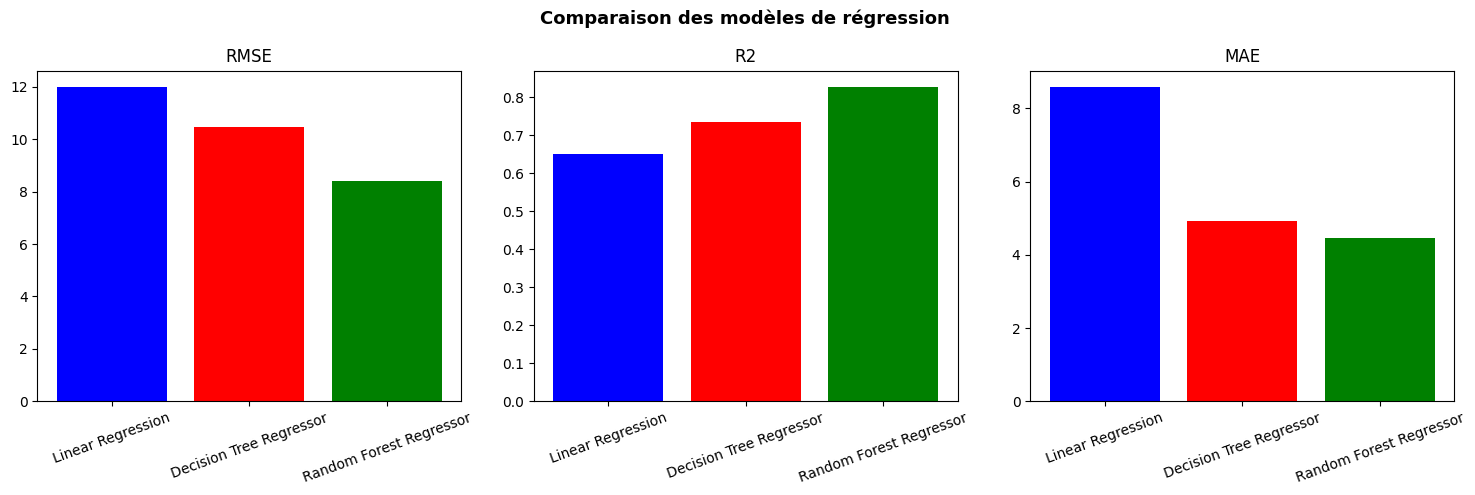

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

def barplot(ax, y):
    ax.bar(df_results["Modèle"], df_results[y], color=["blue", "red", "green"])
    ax.set_title(y)
    ax.tick_params(axis='x', rotation=20)


barplot(ax[0], "RMSE")
barplot(ax[1], "R2")
barplot(ax[2], "MAE")

plt.suptitle("Comparaison des modèles de régression", fontsize=13, fontweight="bold")
plt.tight_layout()

> On remarque que le Random Forest Regressor semble mieux s'en sortir que les autres en expliquant 80% de la variance de l'age. Son erreur moyenne (MAE) est aussi plutôt basse en se trompant de seulement 5 en moyenne.

In [ ]:
pipe_rfr = Pipeline([
    ('prep',  preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    'model__n_estimators'      : [100, 200],
    'model__max_depth'         : [None, 10, 20],
    'model__min_samples_split' : [2, 5],
    'model__min_samples_leaf'  : [1, 2]
}

grid_search = GridSearchCV(
    pipe_rfr,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


/opt/miniconda3/envs/projet_ia_web_bd/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/miniconda3/envs/projet_ia_web_bd/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/miniconda3/envs/projet_ia_web_bd/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/miniconda3/envs/projet_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the

In [ ]:
print(f'Meilleurs paramètres : {grid_search.best_params_}')

Meilleurs paramètres : {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [ ]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_final  = mean_absolute_error(y_test, y_pred_best)
r2_final   = r2_score(y_test, y_pred_best)

print(f'RMSE : {rmse_final:.2f} ans')
print(f'MAE : {mae_final:.2f}  ans')
print(f'R2 : {r2_final:.4f}')

RMSE : 8.40 ans
MAE : 4.56  ans
R2 : 0.8293


> Le modèle étant déjà précis la Grid Search a assez peu amélioré ses performances. Sa moyenne d'erreur absolue reste proche des 5 ans et son R2 est aussi proche de 80%

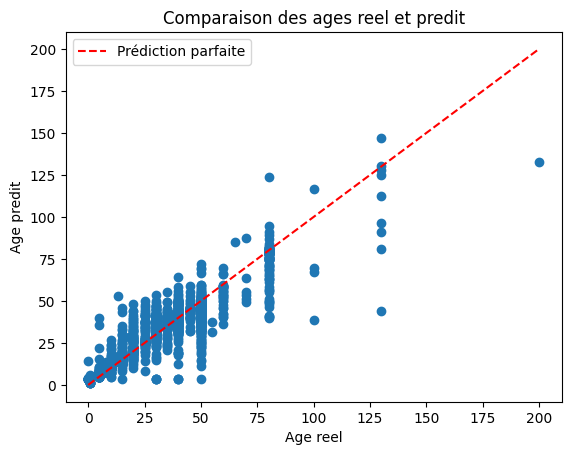

In [ ]:
y_pred = best_model.predict(X_test)
plt.scatter(y_test, y_pred)
plt.xlabel("Age reel")
plt.ylabel("Age predit")
lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, '--', color='red', linewidth=1.5, label='Prédiction parfaite')
plt.legend()
plt.title("Comparaison des ages reel et predit")
plt.show()

> Le modèle se débrouille très bien est gardant des prédictions prche de la prédiction parfaite hormis pour les prédictions > 100 qui deviennent plus compliquées par manque de données

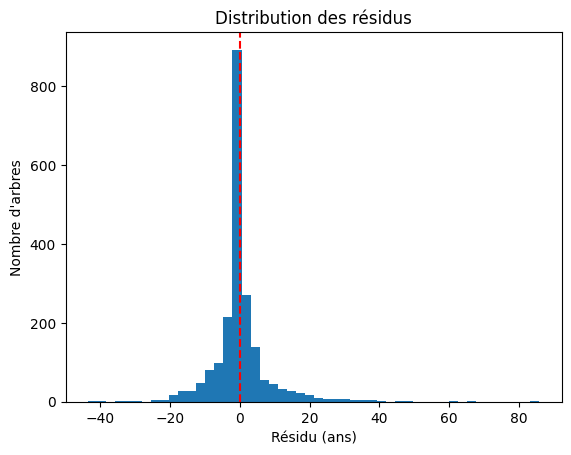

In [ ]:
plt.hist(y_test - y_pred, bins=50)
plt.title("Distribution des résidus")
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Résidu (ans)')
plt.ylabel("Nombre d'arbres")
plt.show()

> On remarque que le modèle donne assez peu de résultats abérrants, la plus grosse partie des arbres se trouve en -5 et +5 ans de l'age reel

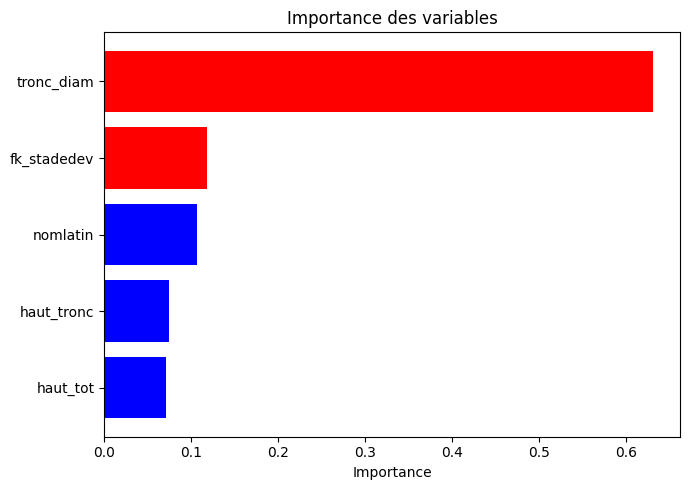

In [ ]:
# Importance des variables
feature_names  = col_num + col_qual
importances    = best_model.named_steps['model'].feature_importances_
df_importance  = pd.DataFrame({'feature': feature_names, 'importance': importances})
df_importance  = df_importance.sort_values('importance', ascending=True)

plt.figure(figsize=(7, 5))
colors_imp = ['red' if i > df_importance['importance'].median() else 'blue'
              for i in df_importance['importance']]
plt.barh(df_importance['feature'], df_importance['importance'], color=colors_imp)
plt.xlabel('Importance')
plt.title('Importance des variables')
plt.tight_layout()
plt.show()

> On remarque que le diamètre du tronc joue un rôle majeur dans la prédiction de l'age de l'arbre, d'autres variables comme le stade de dev de l'arbre et sa hauteur influencent aussi à plus petite échelle. Le nombre de diagnostic et le feuillage n'ont pas l'air d'avoir une influence significative sur l'age. On retrouve donc des estimations cohérentes avec la partie Big Data

# Sauvegarde

In [ ]:
# Sauvegarde du meilleur modèle
joblib.dump(best_model, 'model_age_prediction.pkl')

['model_age_prediction.pkl']

# Chargement du modèle sauvegardé

In [ ]:
# Simulation d'un nouvel arbre
arbre = pd.DataFrame([{
    'haut_tot': 10.0,
    'haut_tronc': 2.0,
    'tronc_diam': 150.0,
    'fk_stadedev': 'adulte',
    'nomlatin': 'TILCOR'
}])

# Chargement depuis le fichier 
model = joblib.load('model_age_prediction.pkl')
prediction = model.predict(arbre)[0]

print(f'Âge prédit : {prediction:.1f} ans')

Âge prédit : 50.5 ans


> Pour référence cette arbre est existant dans la base de données et a un âge estimé à 50 ans